In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from mne.datasets import eegbci

Matplotlib is building the font cache; this may take a moment.


In [2]:
subject = 1
runs = [4, 8, 12]

files = eegbci.load_data(subject, runs)

print(files)

Using default location ~/mne_data for EEGBCI...
Creating C:\Users\diopi\mne_data


Attempting to create new mne-python configuration file:
C:\Users\diopi\.mne\mne-python.json
Could not read the C:\Users\diopi\.mne\mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 03m44s (7.4 MB)
[WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'), WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'), WindowsPath('C:/Users/diopi/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf')]


In [3]:
raw = mne.io.read_raw_edf(files[0], preload=True)

print(raw)
print(raw.info)

Extracting EDF parameters from C:\Users\diopi\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [5]:
data = raw.get_data()

print(data.shape)

print(raw.ch_names)

(64, 20000)
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [6]:
eegbci.standardize(raw)

print(raw.ch_names)

['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']


In [8]:
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>


In [9]:
print(raw.annotations)

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


In [10]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)
print(events[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


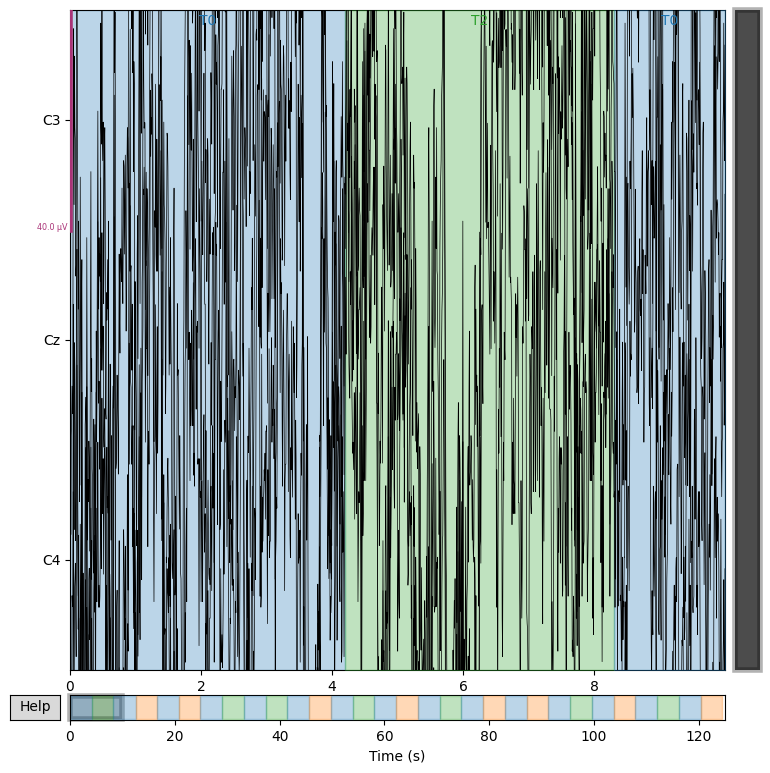

In [14]:
browser = raw.plot(
    duration=10,
    picks=["C3", "Cz", "C4"]
)

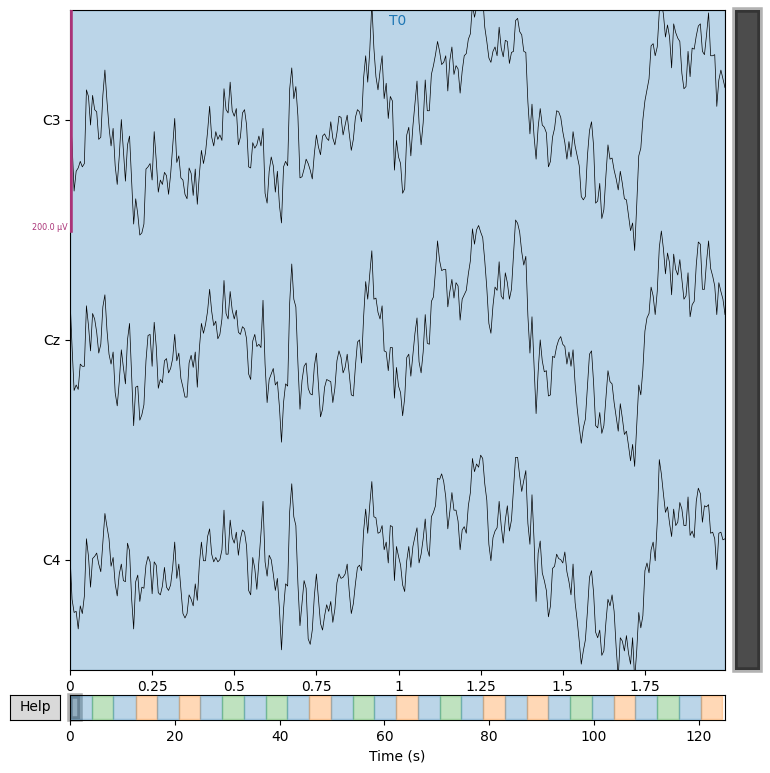

In [15]:
browser = raw.plot(
    duration=2,
    picks=["C3", "Cz", "C4"],
    scalings={"eeg": 100e-6}
)

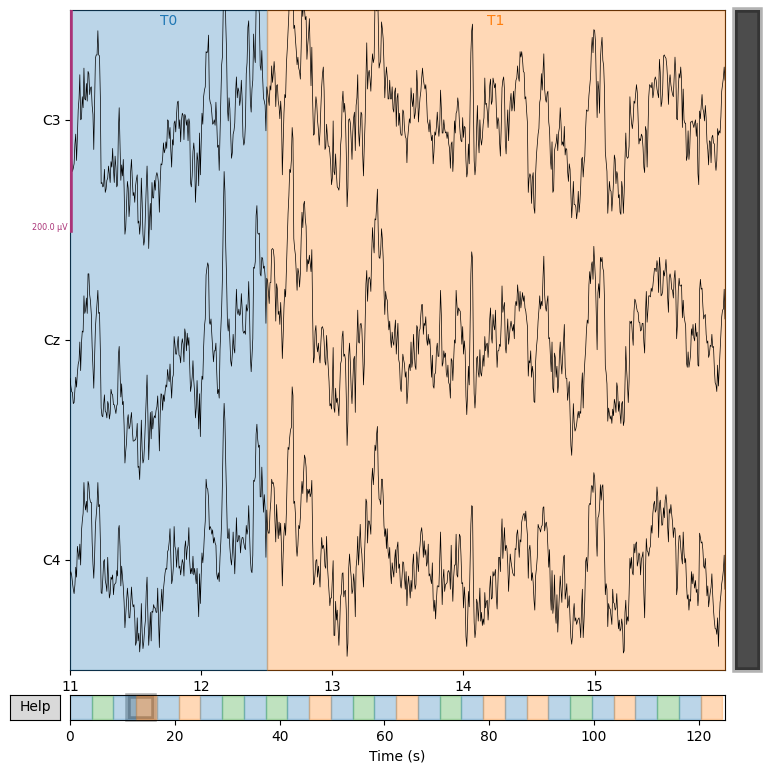

In [16]:
browser = raw.plot(
    start=11,
    duration=5,
    picks=["C3", "Cz", "C4"],
    scalings={"eeg": 100e-6}
)

In [17]:
for i in range(6):
    print(
        raw.annotations.description[i],
        "starts at", raw.annotations.onset[i], "s,",
        "duration =", raw.annotations.duration[i], "s"
    )

T0 starts at 0.0 s, duration = 4.2 s
T2 starts at 4.2 s, duration = 4.1 s
T0 starts at 8.3 s, duration = 4.2 s
T1 starts at 12.5 s, duration = 4.1 s
T0 starts at 16.6 s, duration = 4.2 s
T1 starts at 20.8 s, duration = 4.1 s
